# Trading Strategy Testing Framework

A plug-and-play framework for testing trading strategies with standardized, comparable results.

| Step | What it does | Time |
|------|-------------|------|
| **Setup** | Connect to data providers | Once |
| **Fetch** | Get validated OHLCV data | 1 line |
| **Backtest** | Run strategy, get metrics | 1 line |
| **Optimize** | Find best parameters | 1 line |
| **Scorecard** | 4-page presentation-ready report | 1 line |

---
## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

from datetime import date
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

---
## 1. Data Layer

10 providers available. **Yahoo Finance is the best default** — unlimited history, no key.

| Provider | Key? | History | Limits | Best for |
|----------|------|---------|--------|----------|
| **Yahoo Finance** | No | Unlimited | None | Default — use this |
| **Alpaca** | Free acct | 5-6 years | 200/min | Best backup, reliable API |
| **Twelve Data** | Free | Full | 800/day | Good all-rounder |
| **Finnhub** | Free | ~1 year | 60/min | Recent data, clean API |
| **Polygon.io** | Free | 2 years | 5/min | Delayed but solid |
| **Tiingo** | Free | 20+ years | 1000/day | Deep history |
| **FMP** | Free | Full | 250/day | Decent free tier |
| **Alpha Vantage** | Free | ~100 days | 25/day | Very limited free tier |
| **MarketStack** | Free | Full | 100/month | Testing only |
| **CSV File** | No | Any | None | Your own data |

In [2]:
from data_layer import (
    DataLayer, YahooFinanceProvider,
    # Uncomment + add keys to enable more providers:
    # AlpacaProvider,       # alpaca.markets (free paper account)
    # TwelveDataProvider,   # twelvedata.com
    # FinnhubProvider,      # finnhub.io
    # PolygonProvider,      # polygon.io
    # TiingoProvider,       # tiingo.com
    # FMPProvider,          # financialmodelingprep.com
    # AlphaVantageProvider, # alphavantage.co
    # MarketStackProvider,  # marketstack.com
    # CsvFileProvider,      # local CSV files
)

dl = DataLayer()
dl.add_provider(YahooFinanceProvider())
# dl.add_provider(AlpacaProvider(api_key='...', secret_key='...'))
# dl.add_provider(TwelveDataProvider(api_key='...'))

print(f'Providers: {dl.provider_names}')

/Users/rwalm/Documents/VS Code/Testing Framework/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Providers: ['Yahoo Finance']


In [3]:
# Fetch validated data — one line
symbol = 'SPY'
df = dl.fetch(symbol, date(2022, 1, 1), date(2025, 12, 31))
print(f'{len(df)} bars, {df.index[0].date()} to {df.index[-1].date()}')
df.head()

[PASS] Yahoo Finance — SPY
1003 bars, 2022-01-03 to 2025-12-31


,Open,High,Low,Close,Volume
Date,,,,,
2022-01-03,449.314322,450.776522,447.003149,450.644440,72668200
2022-01-04,452.068865,452.785815,448.635082,450.493469,71178700
2022-01-05,450.125662,450.899210,441.748769,441.843109,104538900
2022-01-06,441.380792,444.144781,439.060148,441.427948,86858900
2022-01-07,441.437434,442.616612,438.324384,439.682800,85111600


---
## 2. Strategies

Import everything, see what's available.

In [4]:
from strategy import *
from backtester import *

list_strategies()

Available strategies:
  - SMACrossover: Classic SMA crossover: go long when the fast SMA crosses above
  - MeanReversion: Z-score mean reversion: long when price dips below the mean,

Options strategies:
  - CoveredCallStrategy: Sell monthly covered calls on underlying.


---
## 3. Backtest

In [5]:
config = BacktestConfig(
    initial_capital=100_000,
    commission_per_order=1.00,   # $1 per trade
    slippage_bps=2.0,            # 2 basis points slippage
)

strat = SMACrossover(fast_period=10, slow_period=30)
result = Backtester(config).run(strat, df)

print(result.summary())

Strategy:           SMA Crossover (10/30)
Period:             4.0 years

--- Performance ---
Total return:       +46.43%
Annual return:      +10.03%
CAGR:               +10.03%
Benchmark (B&H):    +50.91%

--- Risk-Adjusted ---
Sharpe ratio:       0.91
Sortino ratio:      1.05
Calmar ratio:       0.61
SQN:                1.47
Kelly criterion:    0.4572
Alpha (Jensen):     +26.95%
Beta:               0.383

--- Risk ---
Max drawdown:       -16.40%
Avg drawdown:       -1.60%
Max DD duration:    456 bars
Avg DD duration:    18.9 bars
Annual volatility:  11.18%

--- Trades ---
Total trades:       13
Win rate:           61.5%
Profit factor:      3.89
Expectancy:         $3,577.05
Avg win:            +7.42%
Avg loss:           -3.28%
Avg trade return:   +3.31%
Best trade:         +20.25%
Worst trade:        -8.87%
Median trade P&L:   $181.20
Max consec. losses: 2
Avg holding bars:   48.9
Max trade duration: 139 bars
Avg trade duration: 48.9 bars

--- Exposure & Costs ---
Days in market:     

In [6]:
# Equity curve
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(result.equity_curve.index, result.equity_curve, label='Strategy', linewidth=1.5)
ax.plot(result.benchmark_curve.index, result.benchmark_curve, label='Buy & Hold', linewidth=1.2, alpha=0.7, linestyle='--')
ax.set_title(f'{symbol} — {strat.name}', fontsize=14)
ax.set_ylabel('Portfolio Value ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/ng/sj8f6d211bxfr75zt7rh669r0000gn/T/ipykernel_91080/2509794492.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


---
## 4. Optimize Parameters

In [7]:
# Grid search (try every combo)
best, params, results = optimize(
    SMACrossover, df, config,
    maximize='sharpe_ratio',
    method='grid',
    constraint=lambda p: p['fast_period'] < p['slow_period'],
    fast_period=[5, 10, 15, 20],
    slow_period=[30, 40, 50, 60],
)
print(f'Best: {params} -> Sharpe {best.sharpe_ratio:.2f}')

  Constraint filtered: 16 -> 16 combos
Optimizing SMACrossover [grid] over 16 combinations
  Maximizing: sharpe_ratio
  Workers: 15


  Progress: 1/16 (6%) | Elapsed: 2s | ETA: 23s

  Progress: 2/16 (12%) | Elapsed: 2s | ETA: 11s

  Progress: 3/16 (19%) | Elapsed: 2s | ETA: 7s

  Progress: 4/16 (25%) | Elapsed: 2s | ETA: 5s

...

  Progress: 13/16 (81%) | Elapsed: 2s | ETA: 0s

  Progress: 14/16 (88%) | Elapsed: 2s | ETA: 0s

  Progress: 15/16 (94%) | Elapsed: 2s | ETA: 0s

  Progress: 16/16 (100%) | Elapsed: 2s | ETA: 0s


Optimization complete in 1.7s
  Best sharpe_ratio: 1.0381
  Best params: {'fast_period': 5, 'slow_period': 40}
Best: {'fast_period': 5, 'slow_period': 40} -> Sharpe 1.04


In [8]:
# Optuna (smart Bayesian search — better for large parameter spaces)
best_opt, params_opt, results_opt = optimize(
    SMACrossover, df, config,
    maximize='sharpe_ratio',
    method='optuna',
    n_trials=30,
    constraint=lambda p: p['fast_period'] < p['slow_period'],
    fast_period=[5, 10, 15, 20, 25],
    slow_period=[20, 30, 40, 50, 60, 70],
)
print(f'\nOptuna best: {params_opt} -> Sharpe {best_opt.sharpe_ratio:.2f}, Return {best_opt.total_return_pct:+.1f}%')


Optimizing SMACrossover [optuna] for 30 trials
  Maximizing: sharpe_ratio
  Parameters: fast_period=[5, 10, 15, 20, 25], slow_period=[20, 30, 40, 50, 60, 70]
  Progress: 1/30 (3%) | Elapsed: 0s | ETA: 1s

  Progress: 2/30 (7%) | Elapsed: 0s | ETA: 1s

  Progress: 3/30 (10%) | Elapsed: 0s | ETA: 1s

  Progress: 4/30 (13%) | Elapsed: 0s | ETA: 1s

  Progress: 5/30 (17%) | Elapsed: 0s | ETA: 1s

...

  Progress: 26/30 (87%) | Elapsed: 1s | ETA: 0s

  Progress: 27/30 (90%) | Elapsed: 1s | ETA: 0s

  Progress: 28/30 (93%) | Elapsed: 1s | ETA: 0s

  Progress: 29/30 (97%) | Elapsed: 1s | ETA: 0s


Optimization complete in 0.8s
  Best sharpe_ratio: 1.0381
  Best params: {'fast_period': 5, 'slow_period': 40}

Optuna best: {'fast_period': 5, 'slow_period': 40} -> Sharpe 1.04, Return +53.1%


Heatmap saved to: heatmap.png


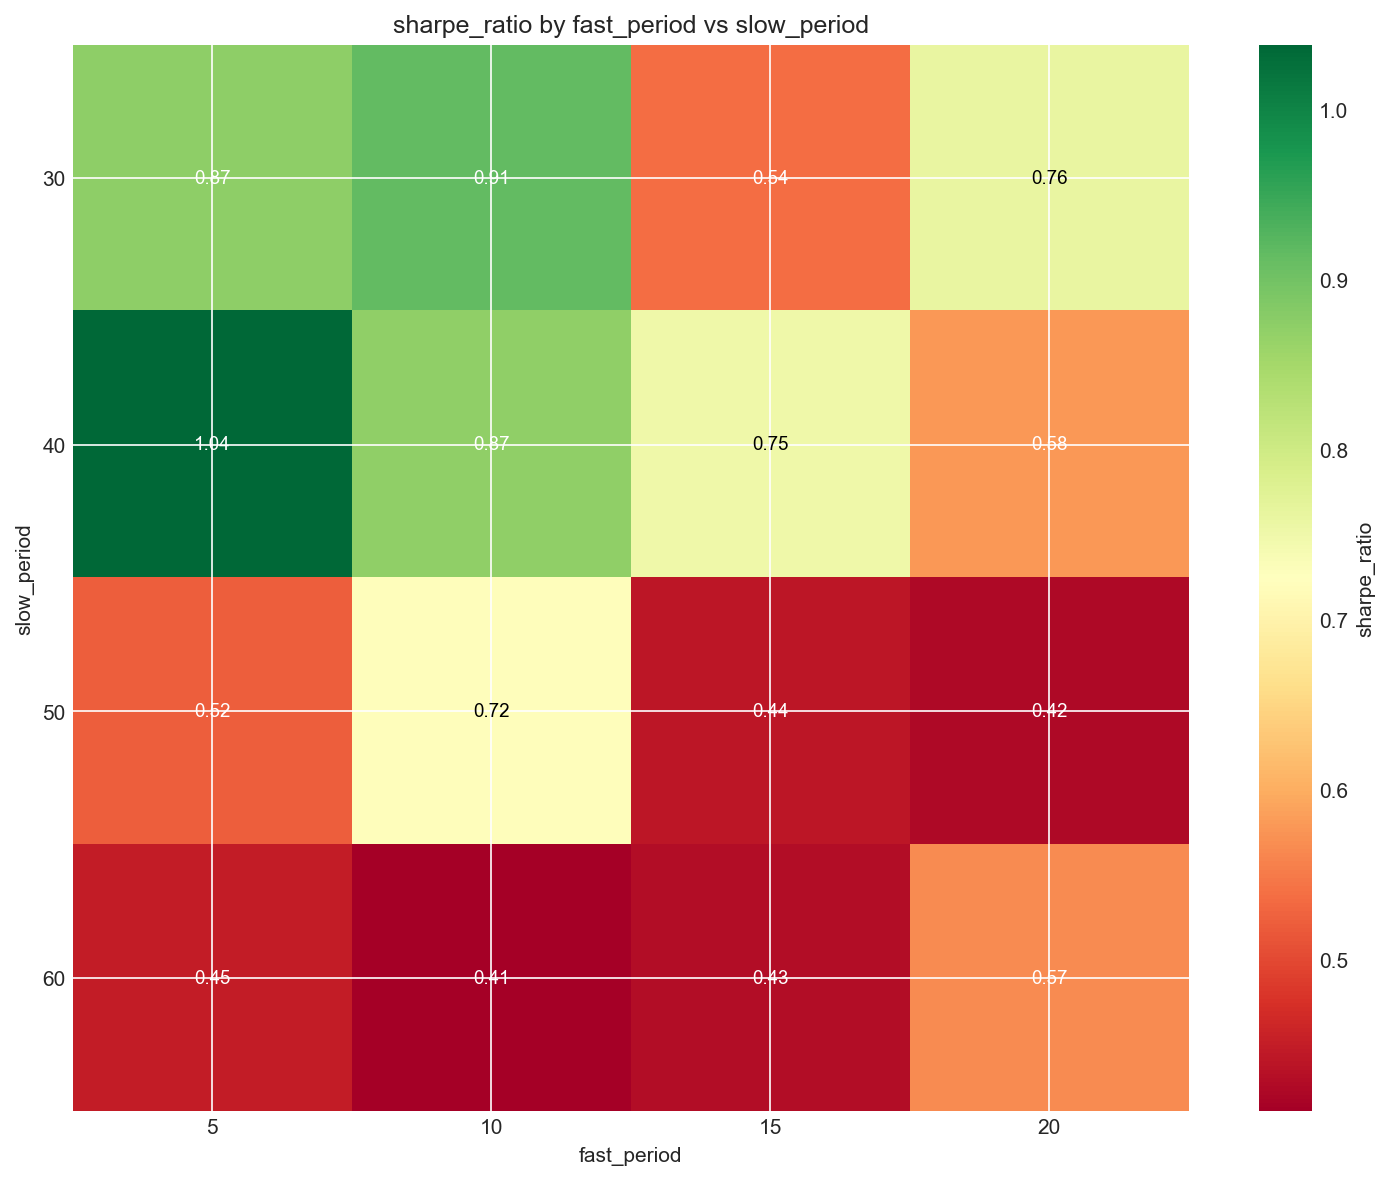

In [9]:
# Parameter sensitivity heatmap
plot_heatmap(results, 'fast_period', 'slow_period', 'sharpe_ratio',
             output_path='heatmap.png')

from IPython.display import Image, display
display(Image('heatmap.png'))

---
## 5. Validate on Synthetic Data

In [10]:
# Test against oscillating, trending, and random walk data
run_validation_suite(strat, config=config)

Validation Suite: SMA Crossover (10/30)



  Oscillating (mean-reverting):
    Return: -85.03%  |  Sharpe: -10.91  |  Trades: 19  |  Win rate: 0%  |  Max DD: -85.03%

  Trending (strong uptrend):
    Return: +71.83%  |  Sharpe: 17.15  |  Trades: 0  |  Win rate: 0%  |  Max DD: -0.15%



  Random Walk (no edge):
    Return: -16.76%  |  Sharpe: -1.25  |  Trades: 7  |  Win rate: 0%  |  Max DD: -18.46%


{'Oscillating (mean-reverting)': BacktestResult(strategy_name='SMA Crossover (10/30)', trades=[Trade(entry_date=Timestamp('2020-02-14 00:00:00'), entry_price=np.float64(104.87207134707643), exit_date=Timestamp('2020-03-03 00:00:00'), exit_price=np.float64(95.07324971980475), quantity=953, direction='LONG', gross_pnl=np.float64(-9338.277010789909), fees=np.float64(40.10920618863537), net_pnl=np.float64(-9378.386216978544), return_pct=np.float64(-9.343595011909567), holding_bars=12, entry_reason='enter_long', exit_reason='exit'), Trade(entry_date=Timestamp('2020-03-19 00:00:00'), entry_price=np.float64(105.0221270475956), exit_date=Timestamp('2020-04-07 00:00:00'), exit_price=np.float64(94.64337134846231), quantity=863, direction='LONG', gross_pnl=np.float64(-8956.866168352033), fees=np.float64(36.46190812698919), net_pnl=np.float64(-8993.328076479022), return_pct=np.float64(-9.882446671861523), holding_bars=13, entry_reason='enter_long', exit_reason='exit'), Trade(entry_date=Timestamp('

---
## 6. Trade Distributions

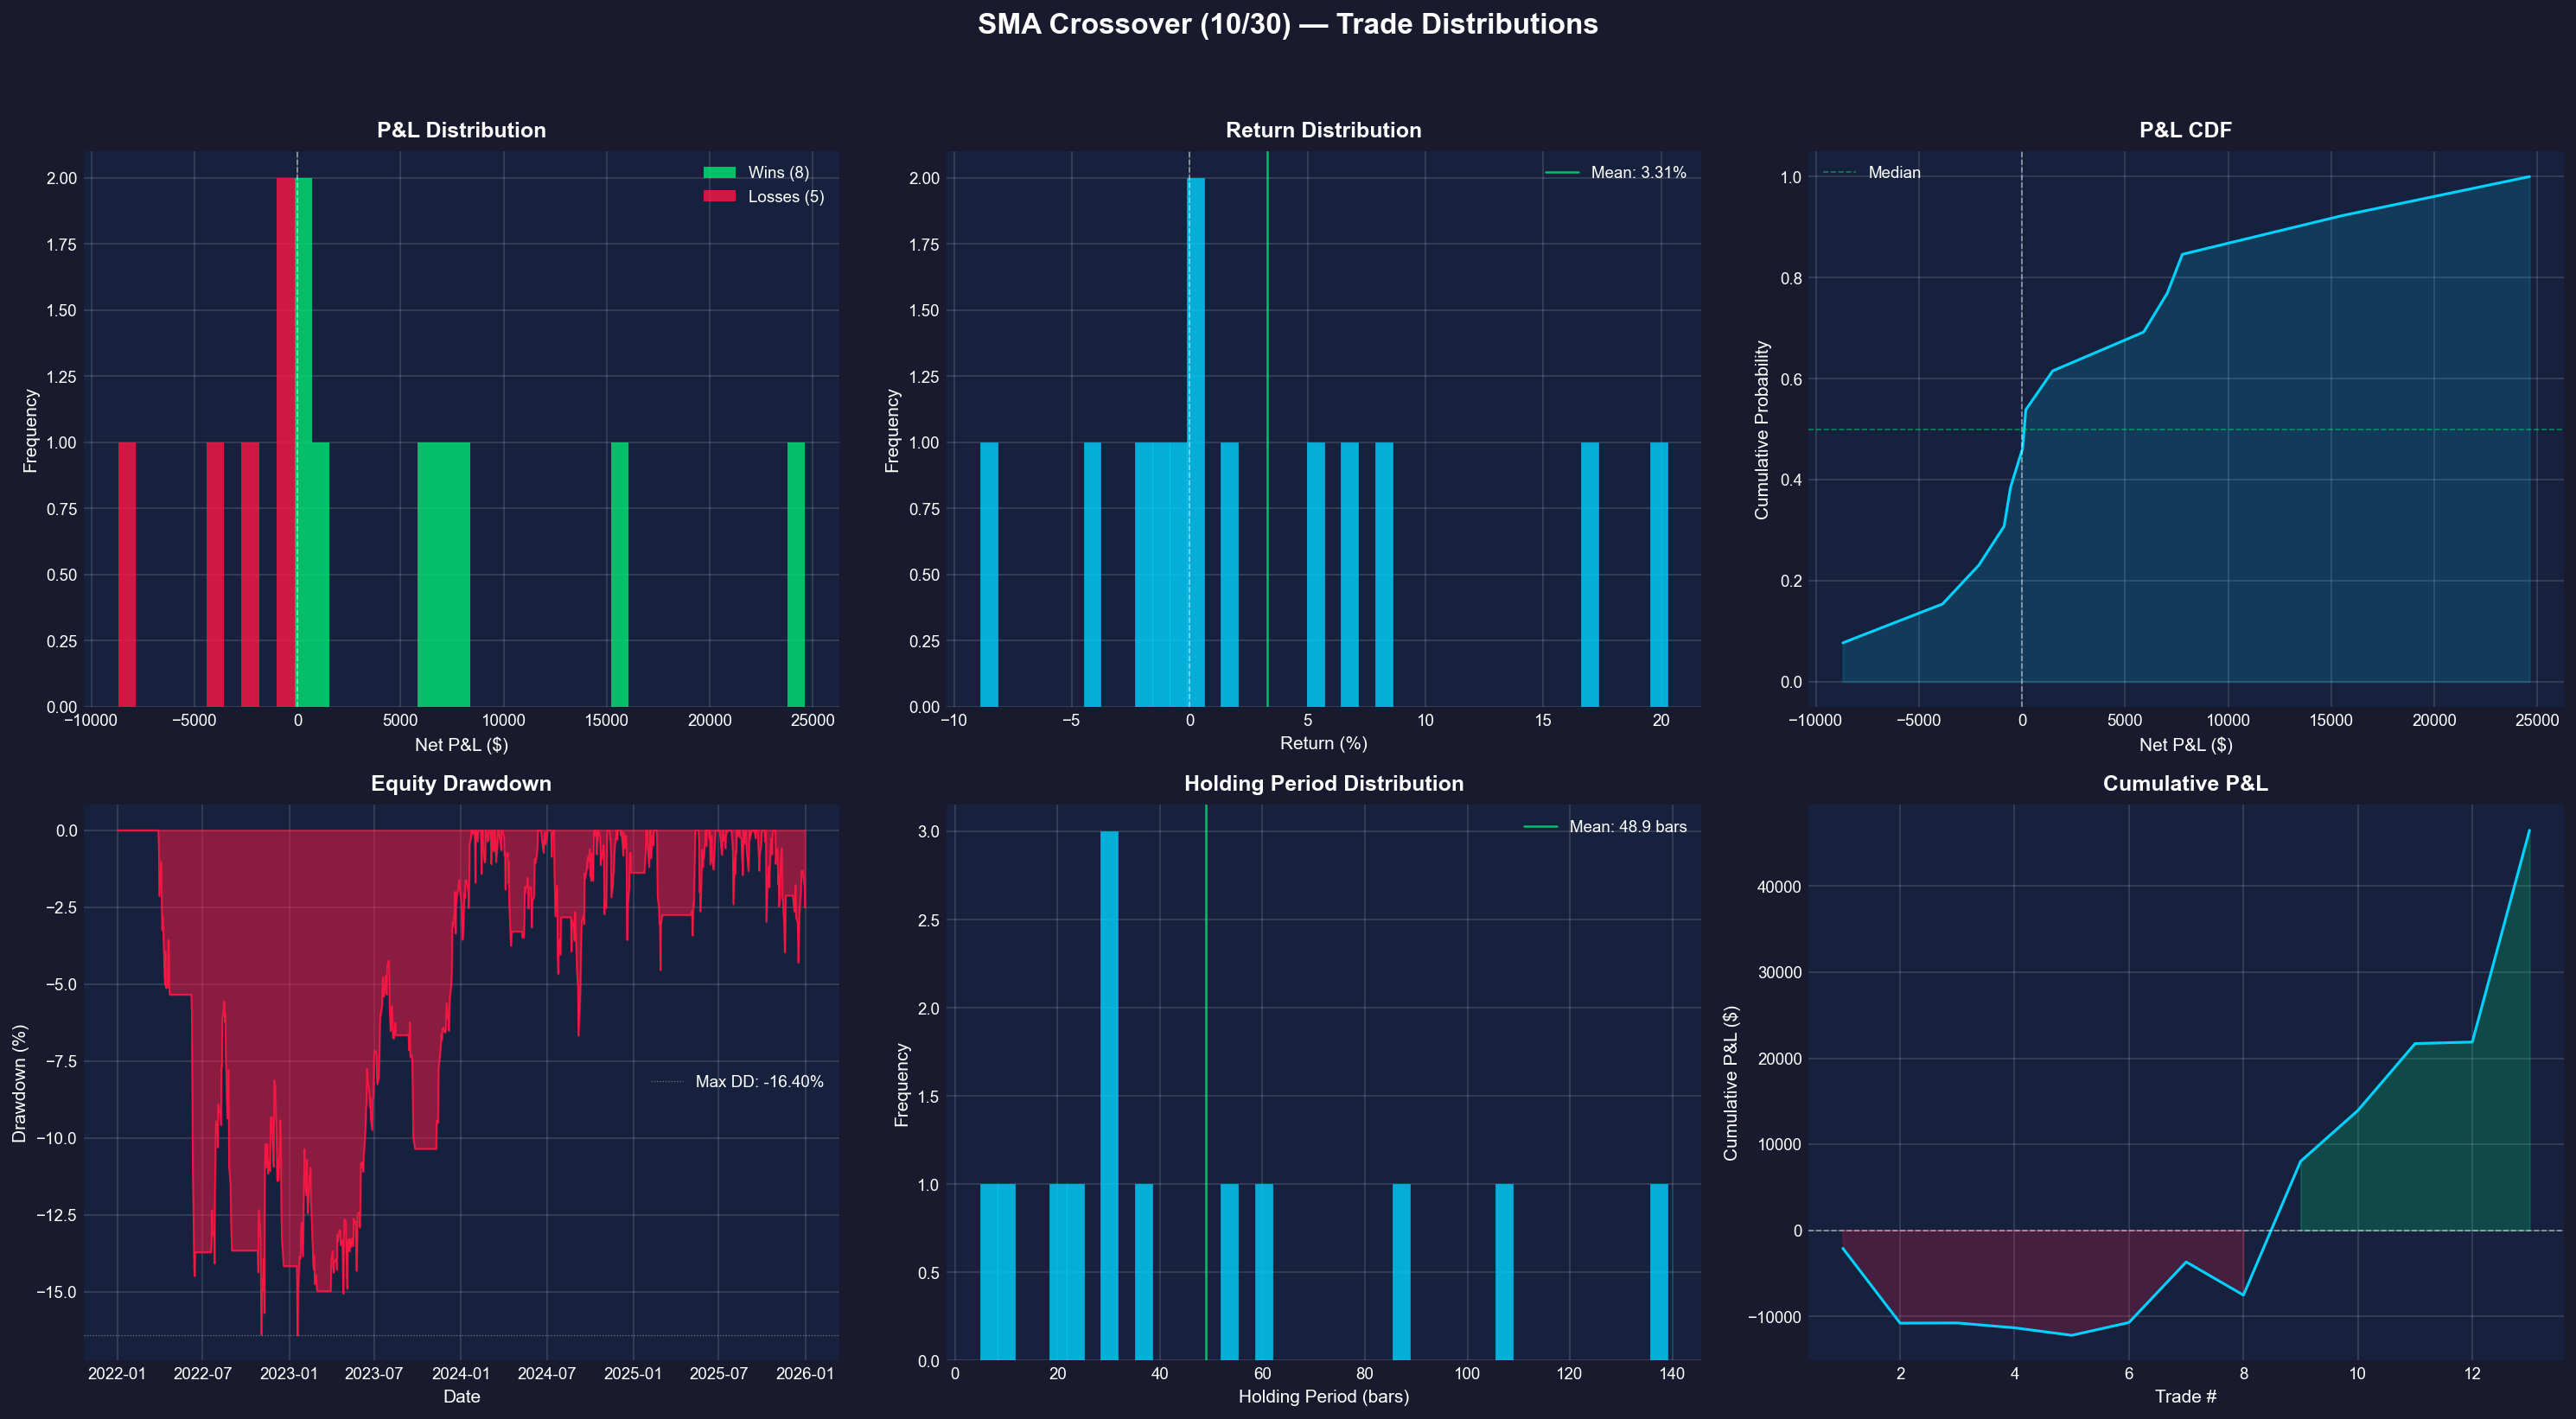

In [11]:
generate_distribution_plots(result, 'distributions.png')
display(Image('distributions.png'))

---
## 7. Scorecard

One call generates 4 presentation slides:
1. Bar-Based Backtest (equity curve + metrics)
2. Monte Carlo Simulation (placeholder — awaiting module)
3. Event-Driven Backtest (placeholder — awaiting module)
4. Strategy Scorecard (grades from all tests)

Page 1 (Bar-Based Backtest):    report_bartest.png
Page 2 (Monte Carlo):           report_montecarlo.png
Page 3 (Event-Driven Backtest): report_eventdriven.png
Page 4 (Strategy Scorecard):    report_scorecard.png

Page 1: Bar-Based Backtest


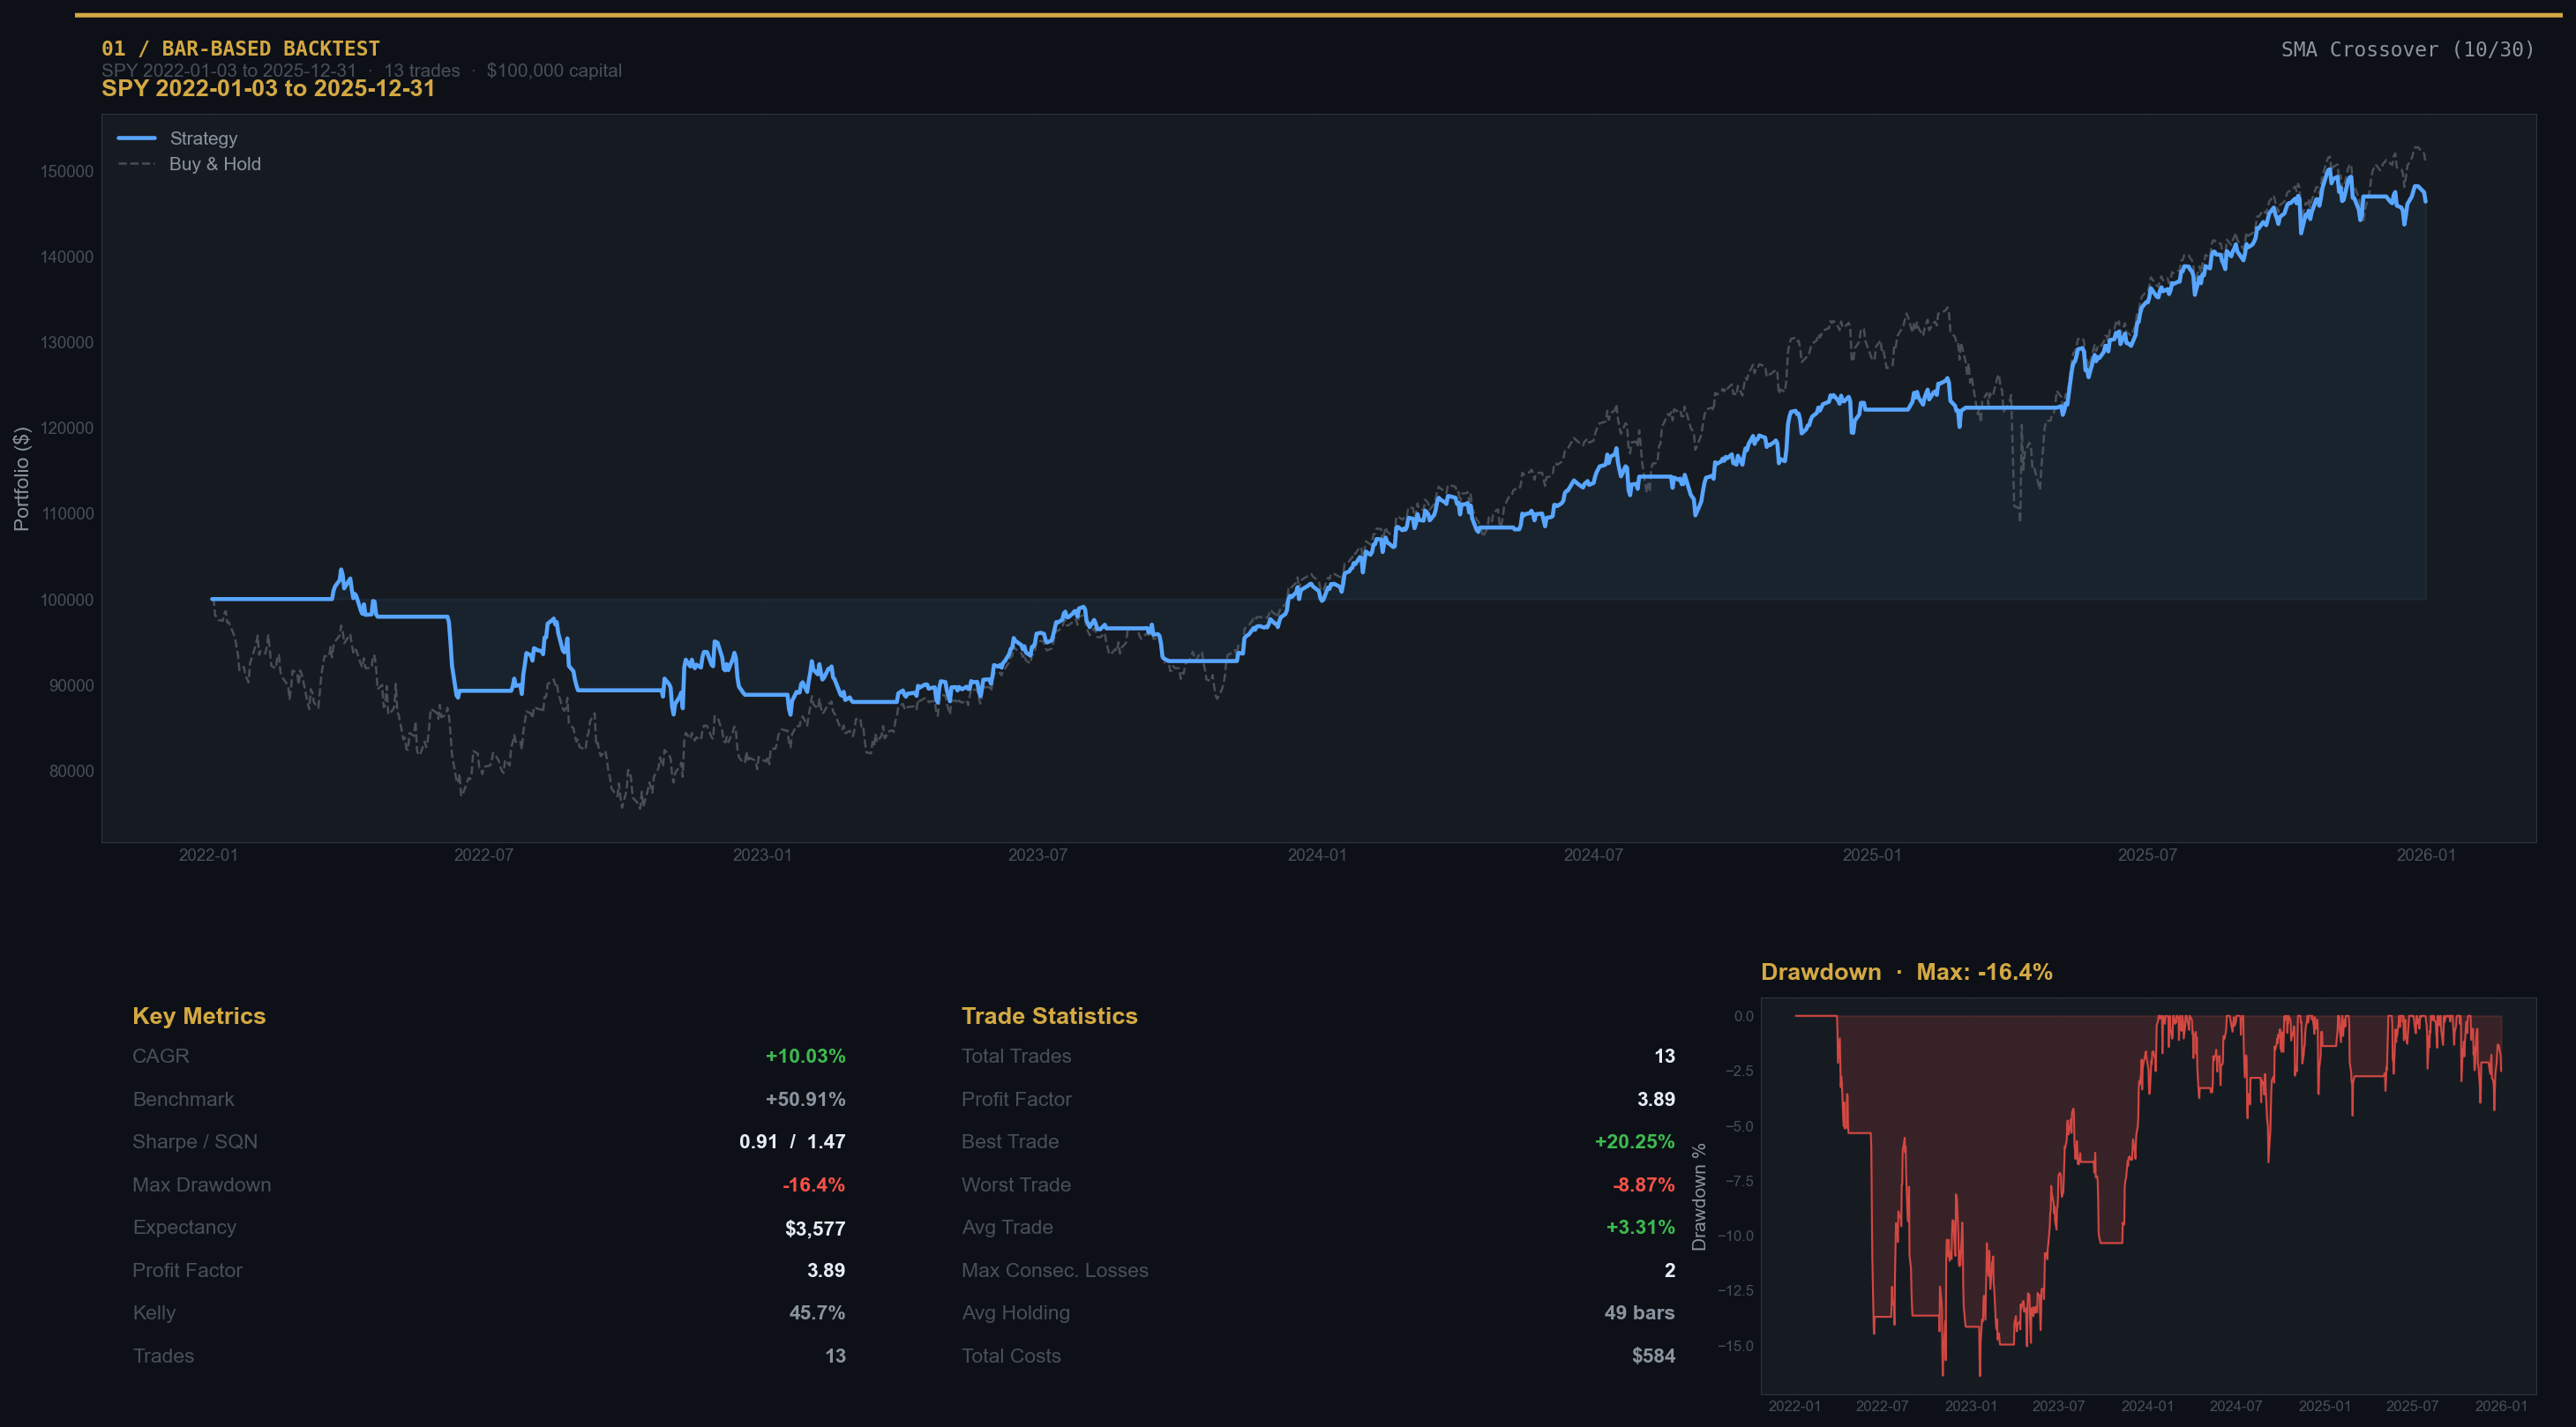


Page 2: Monte Carlo (placeholder)


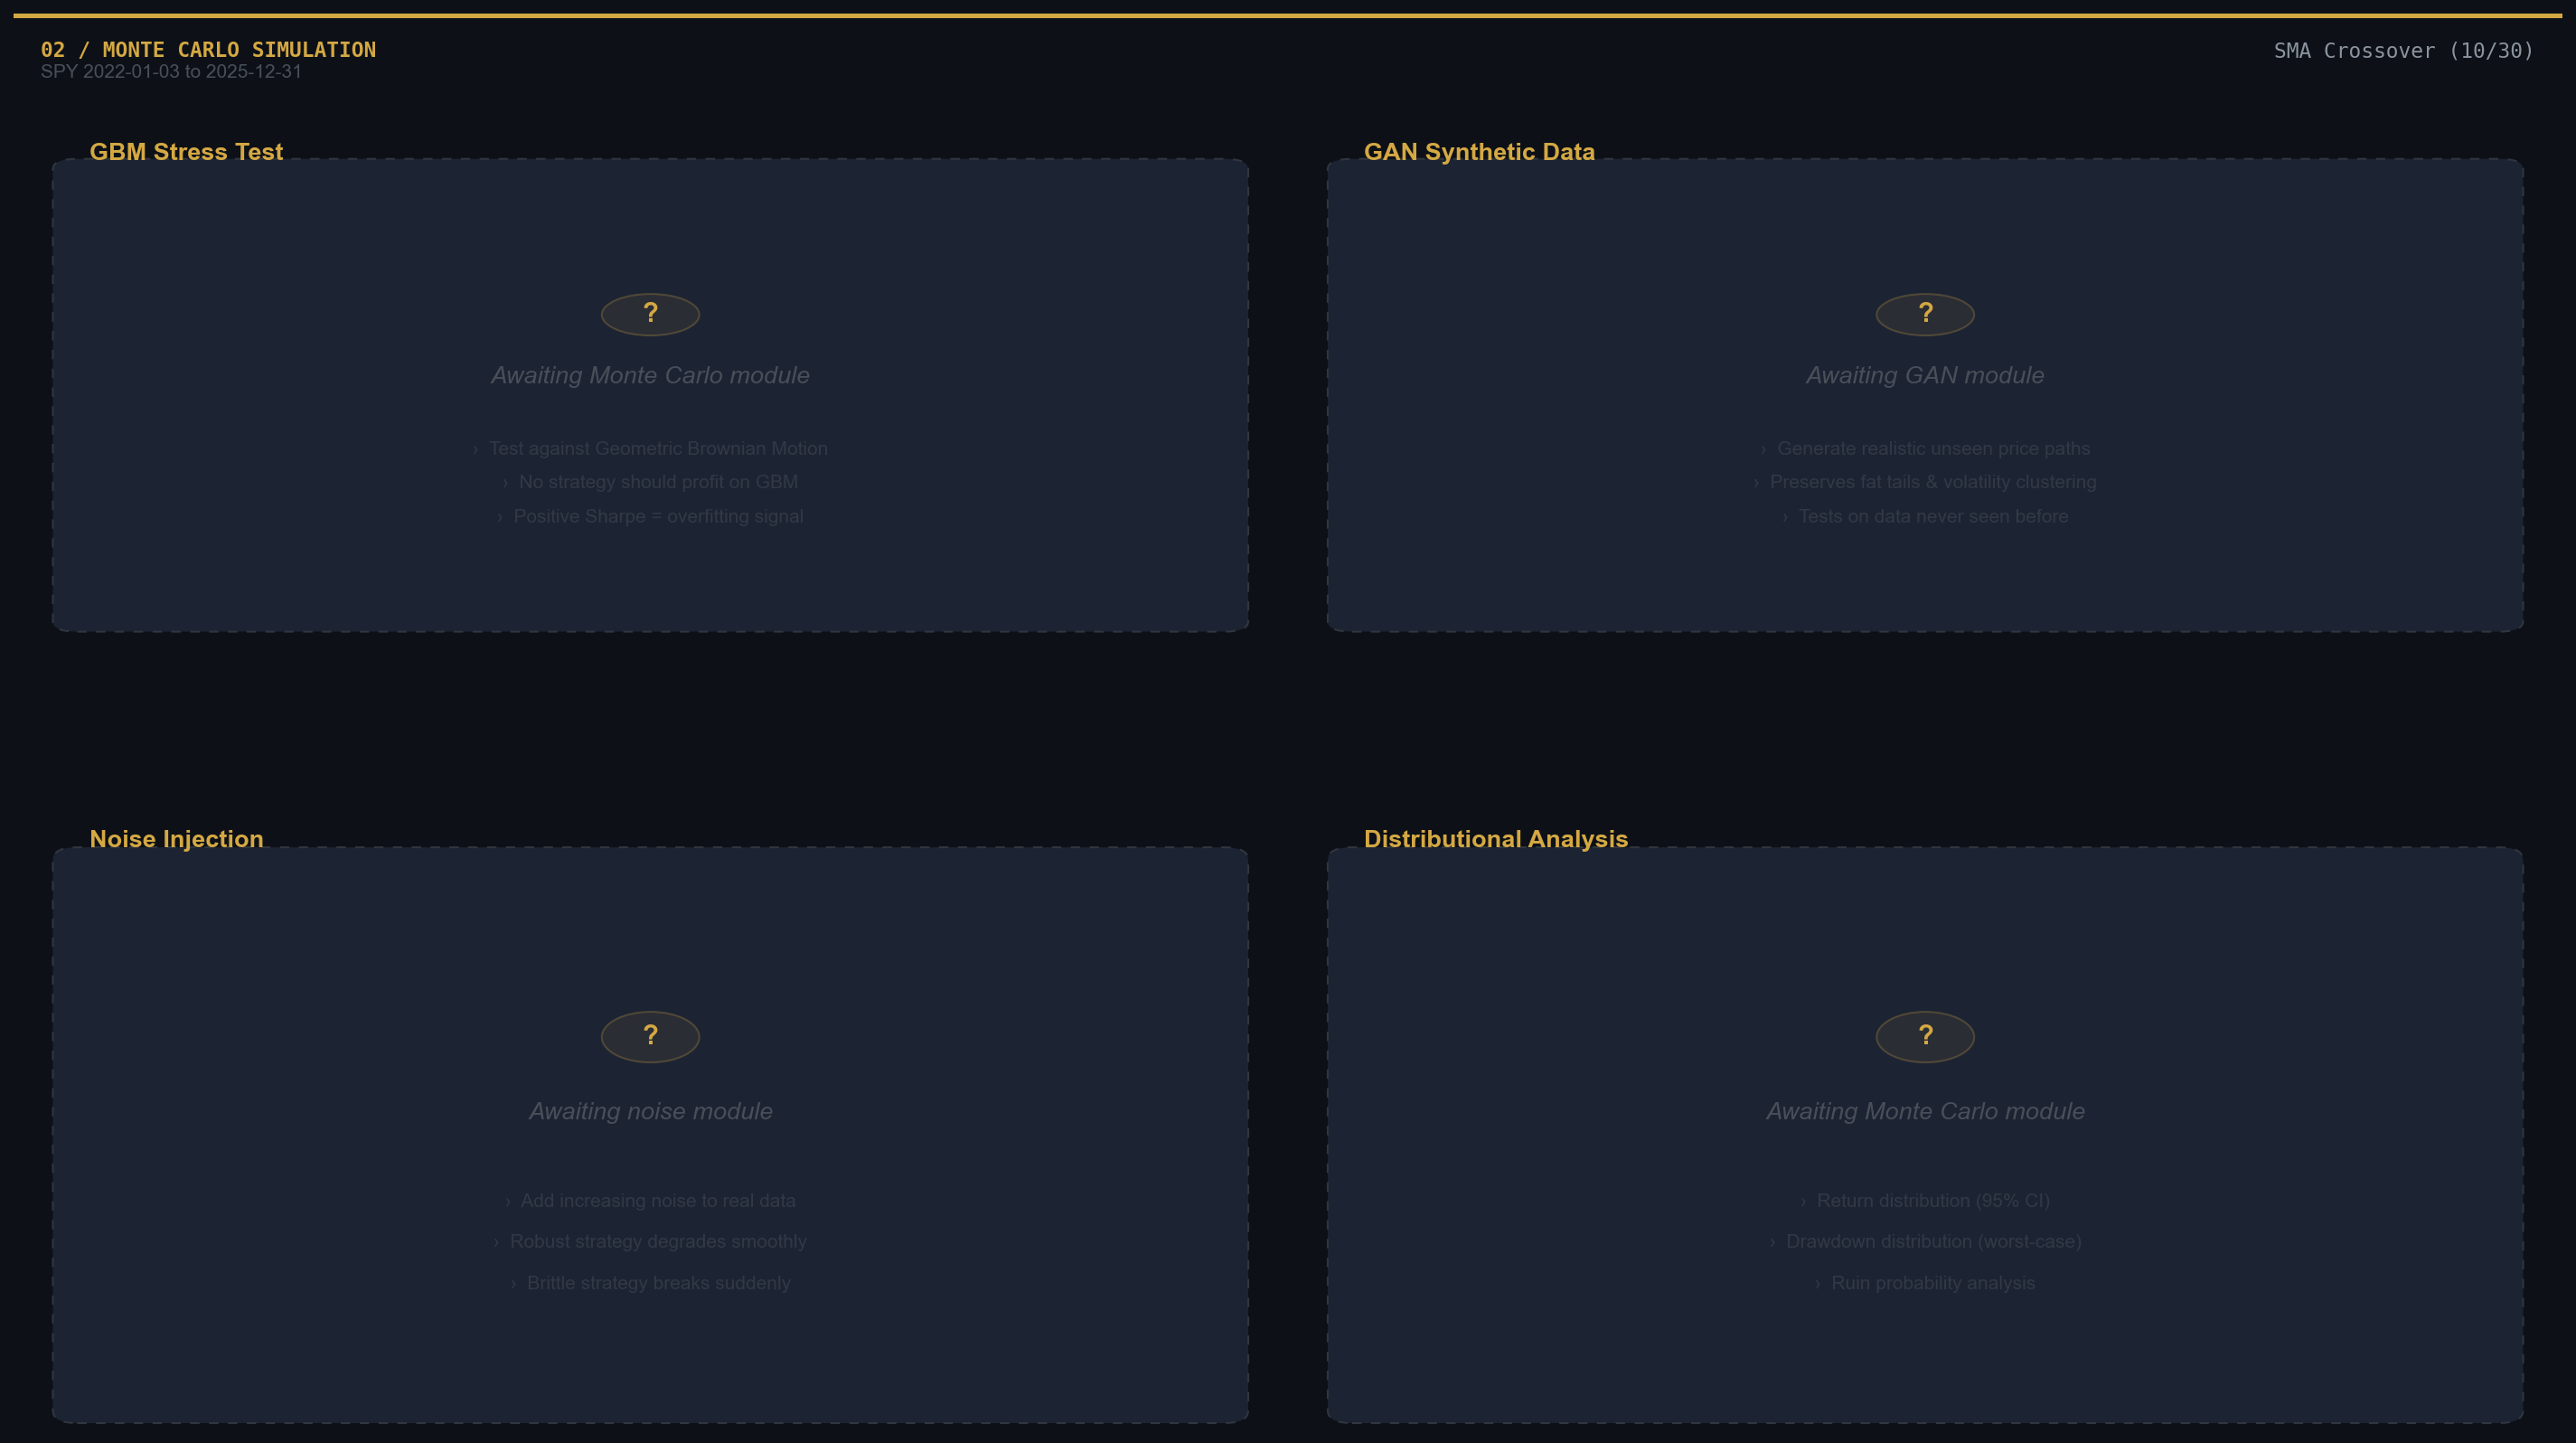


Page 3: Event-Driven (placeholder)


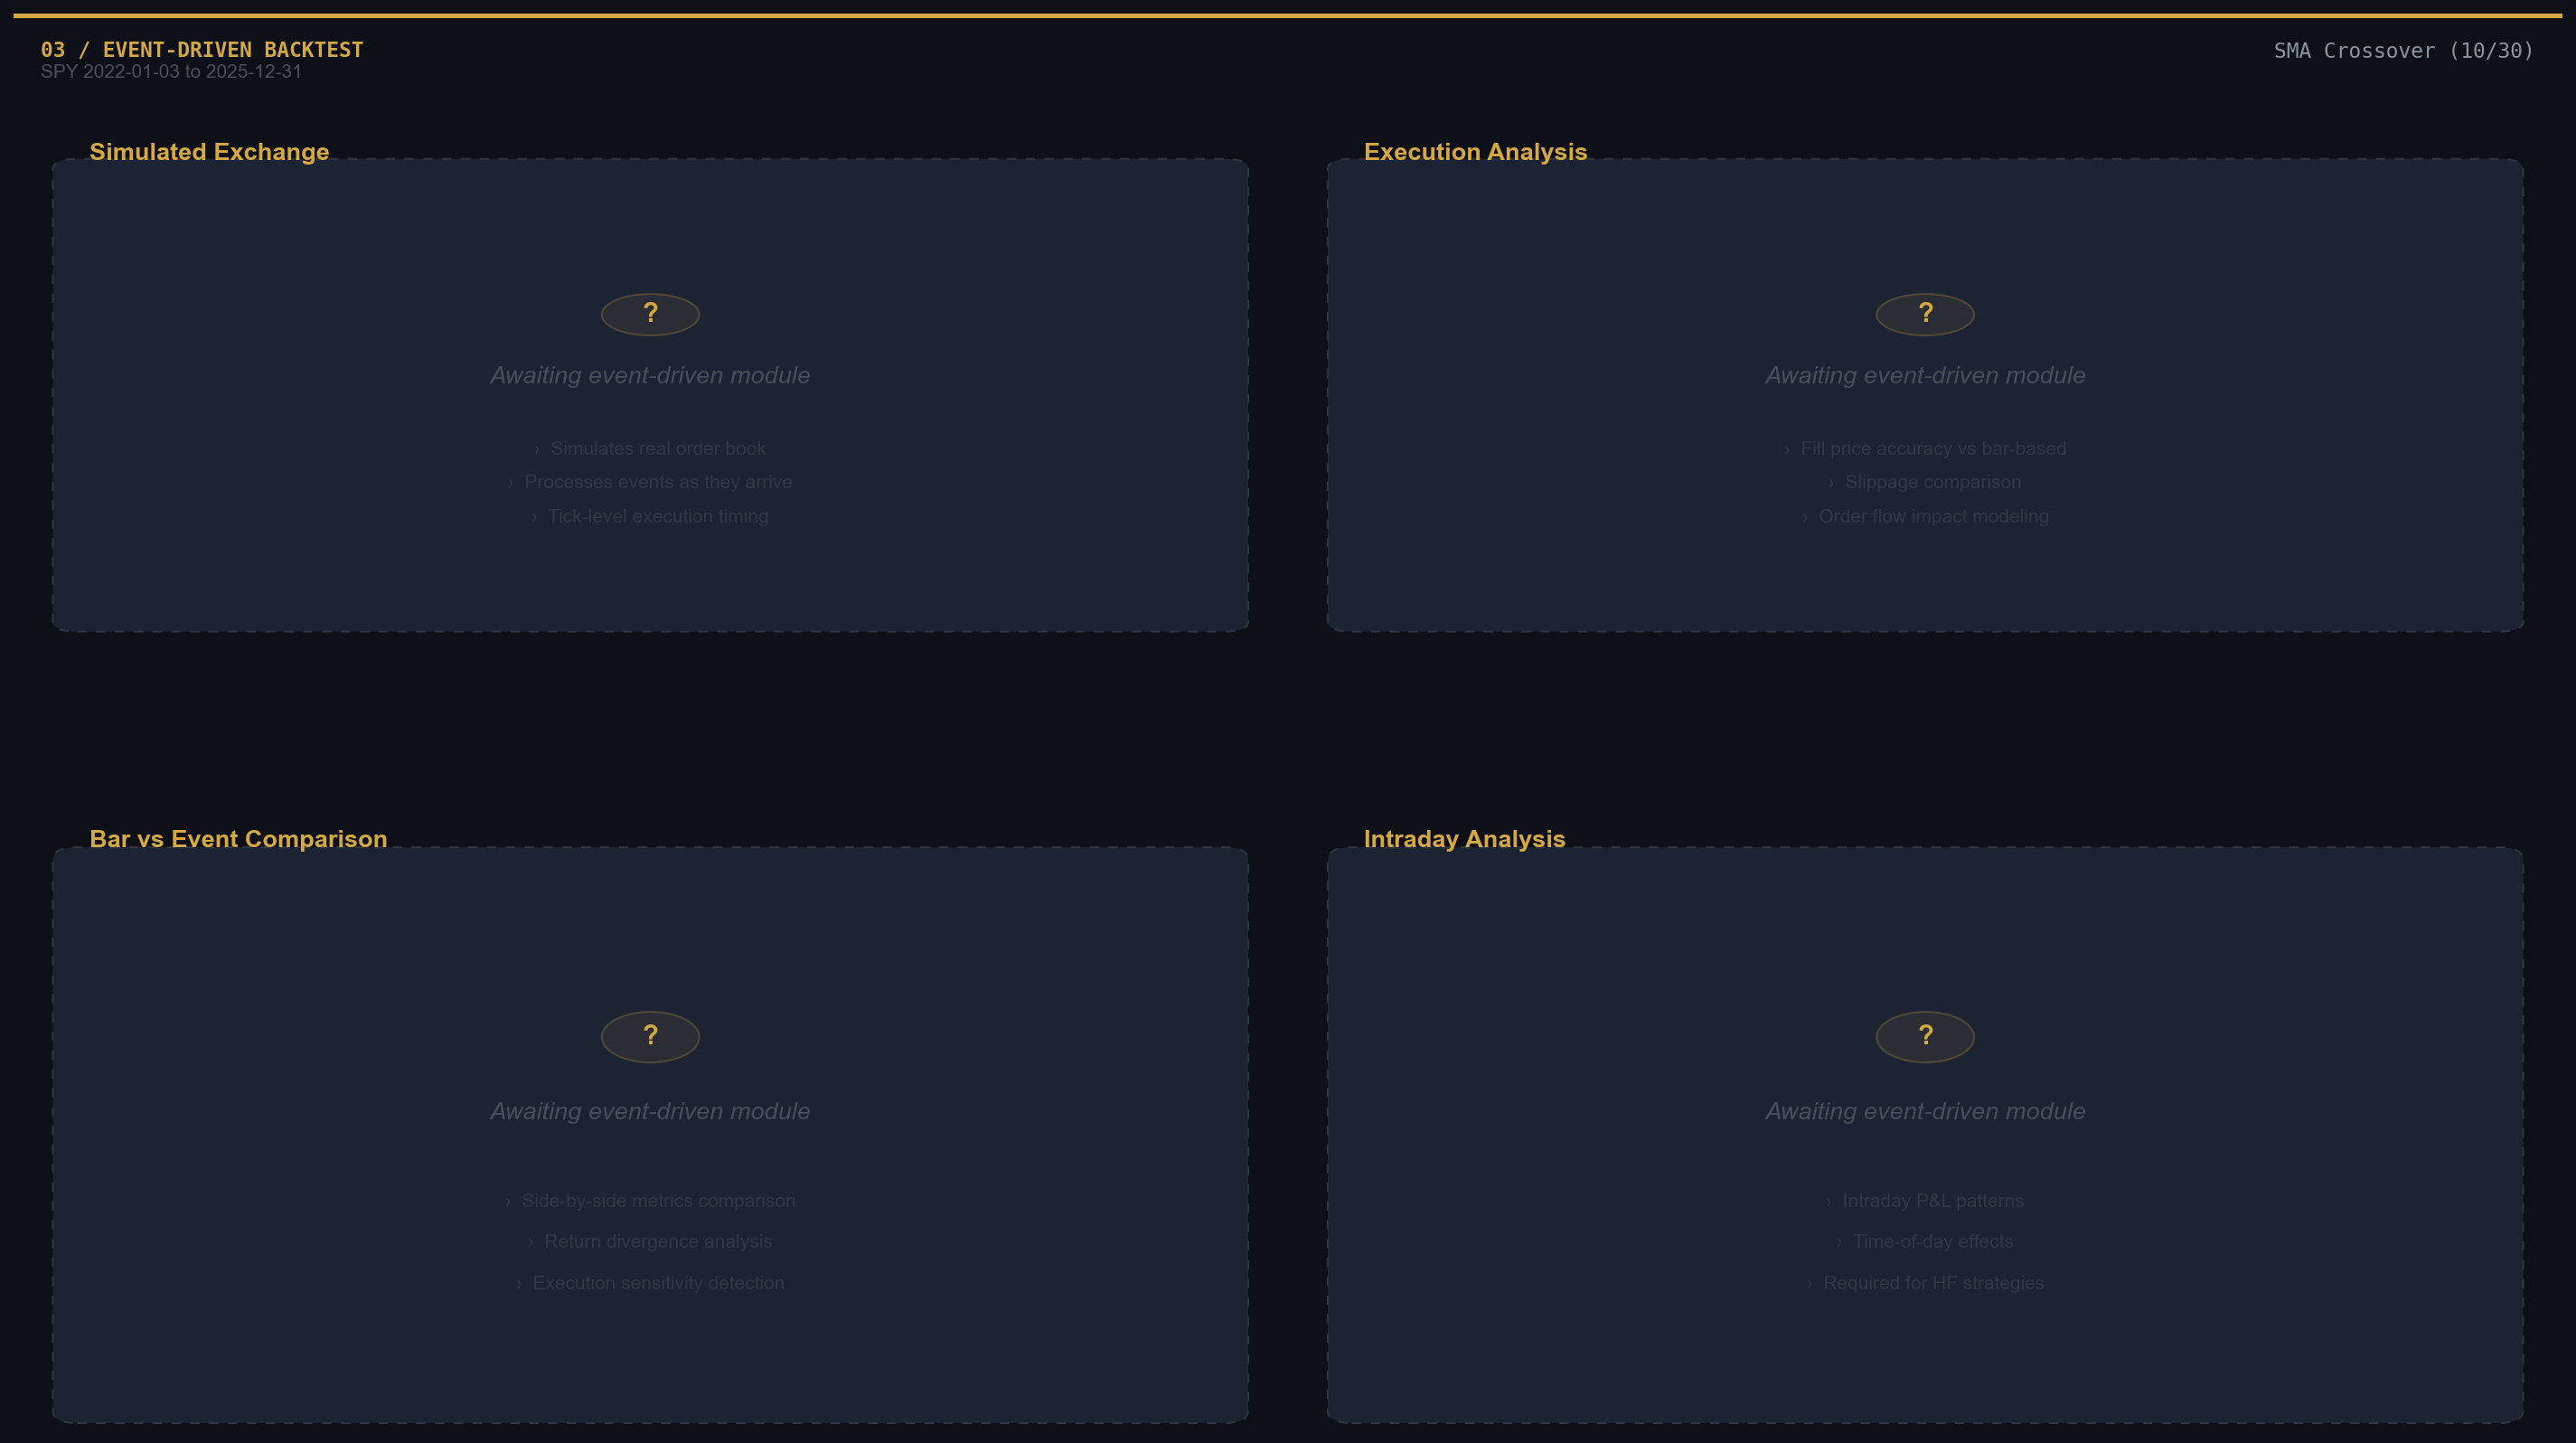


Page 4: Strategy Scorecard


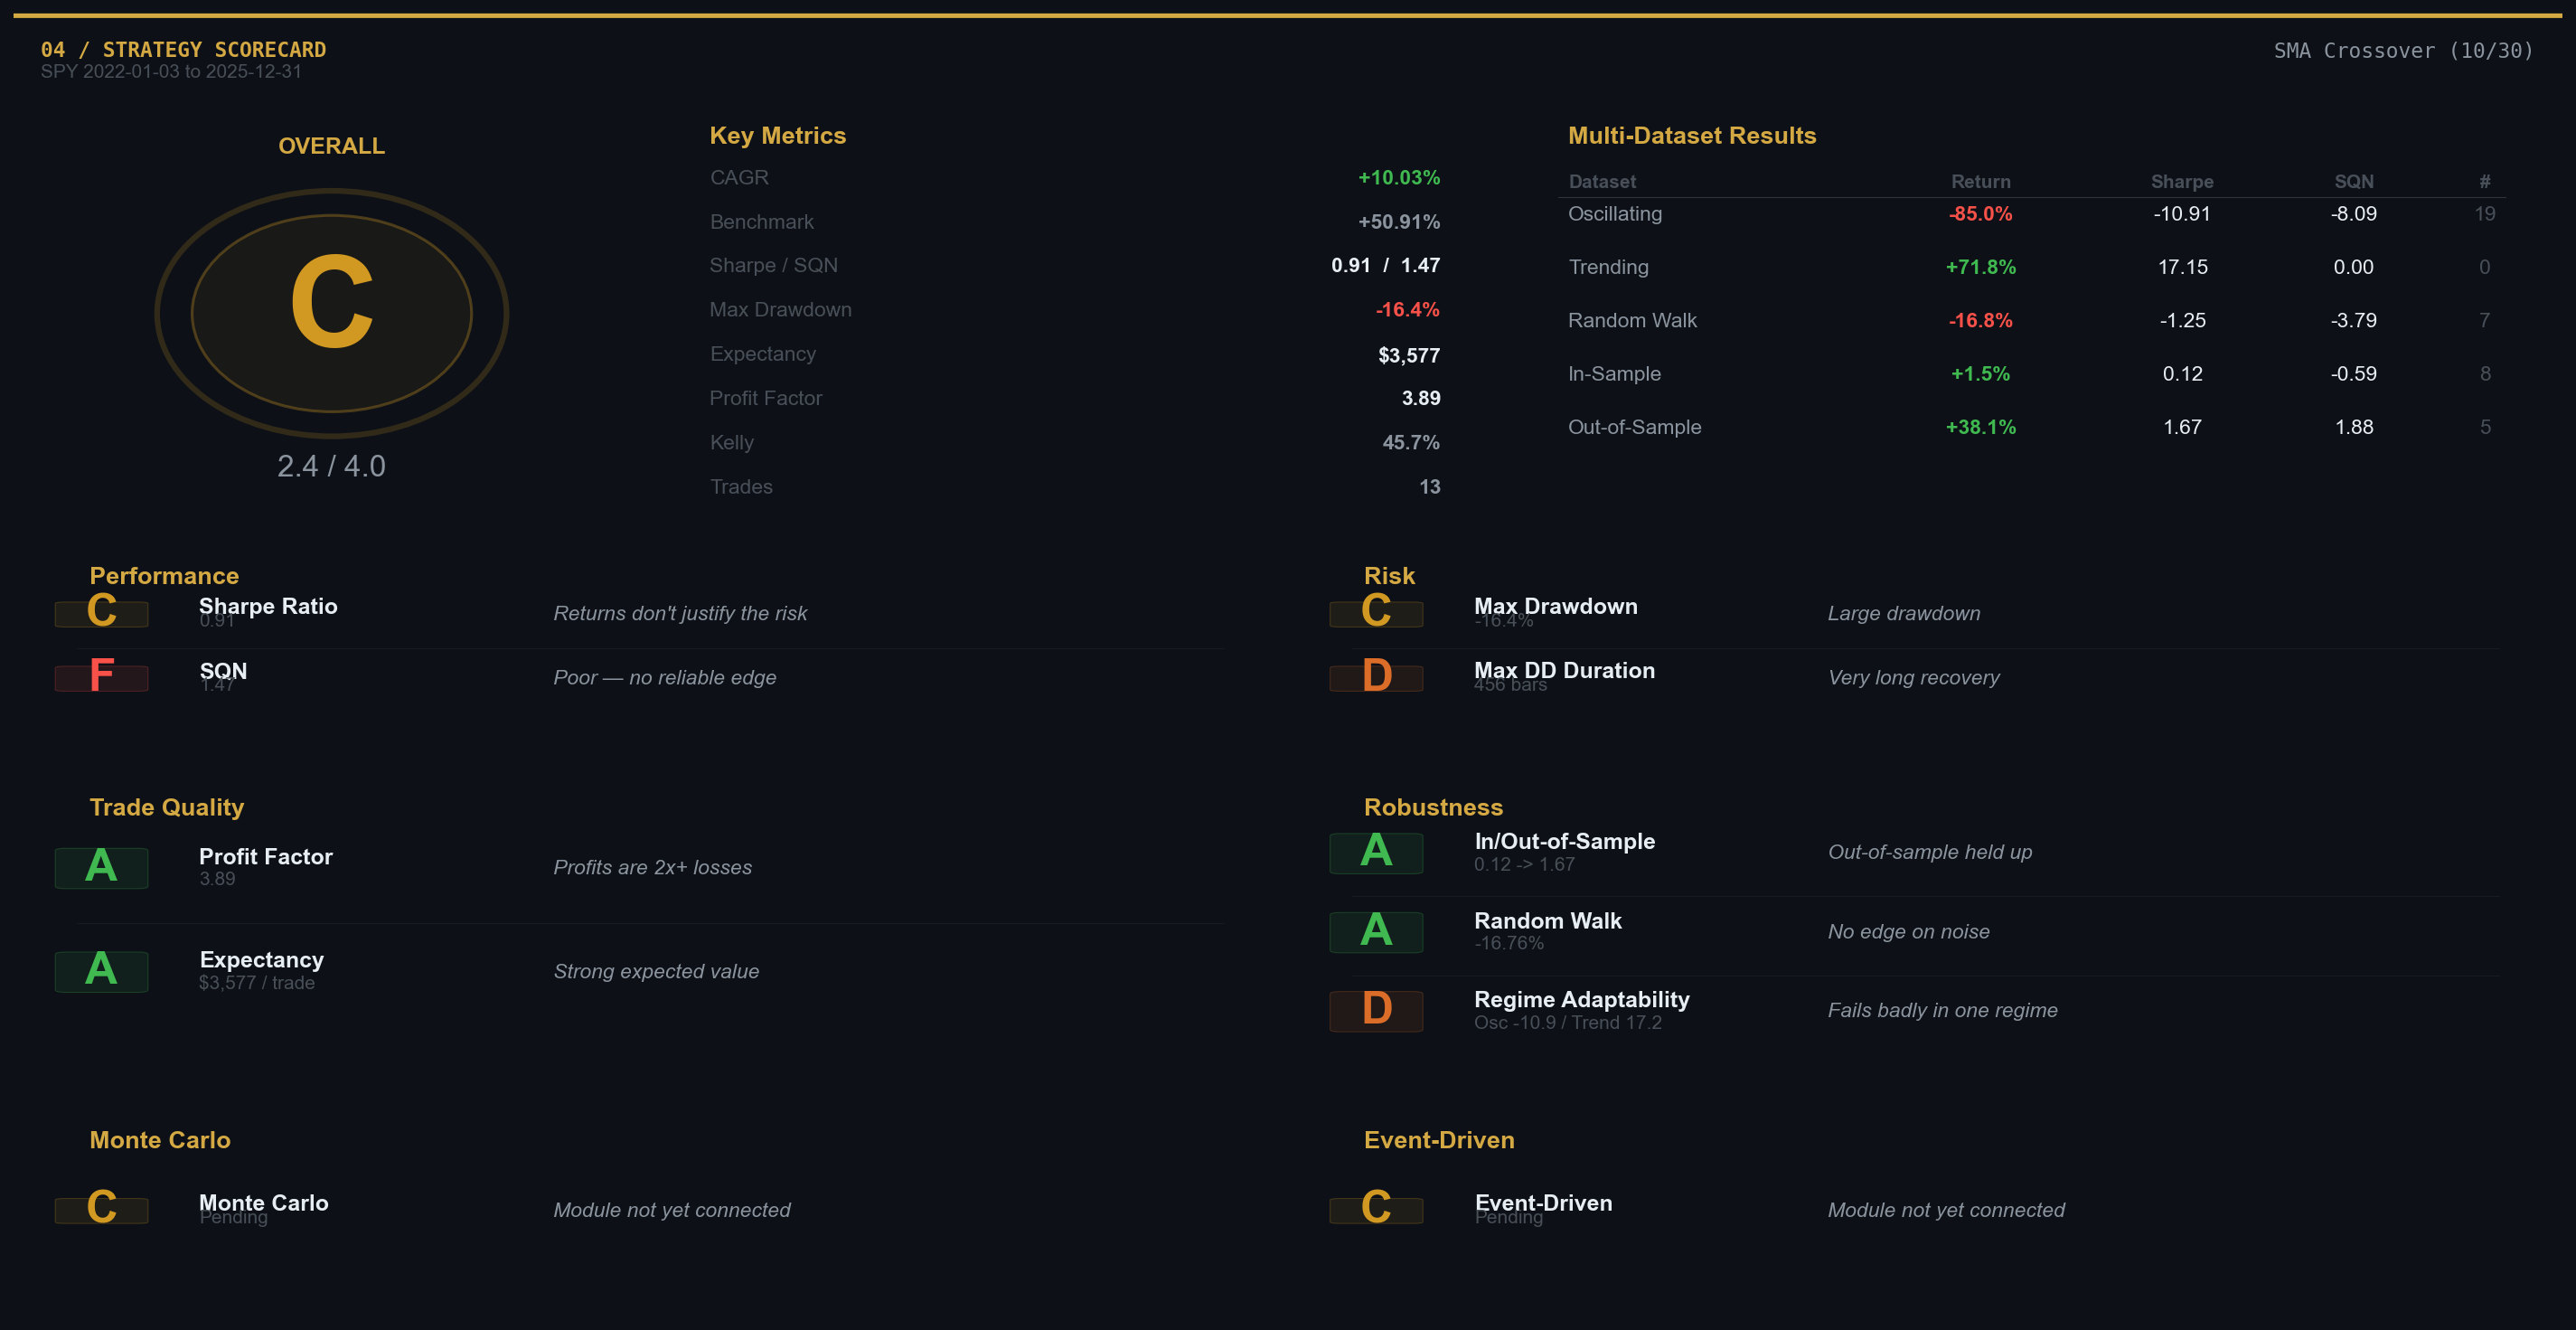

In [12]:
generate_scorecard(
    strategy=strat,
    df=df,
    config=config,
    symbol=symbol,
    output_path='report.png',
)

print('\nPage 1: Bar-Based Backtest')
display(Image('report_bartest.png'))
print('\nPage 2: Monte Carlo (placeholder)')
display(Image('report_montecarlo.png'))
print('\nPage 3: Event-Driven (placeholder)')
display(Image('report_eventdriven.png'))
print('\nPage 4: Strategy Scorecard')
display(Image('report_scorecard.png'))

---
## Writing Your Own Strategy

**Signal mode** (simple):
```python
from strategy.base import Strategy, Signal
from strategy.helpers import crossover

class MyStrategy(Strategy):
    def __init__(self, period=20):
        self.period = period

    @property
    def name(self): return f'My Strategy ({self.period})'

    def generate_signals(self, df):
        signals = pd.Series(Signal.HOLD, index=df.index)
        sma = df['Close'].rolling(self.period).mean()
        for i in range(1, len(df)):
            if crossover(df['Close'].values[:i+1], sma.values[:i+1]):
                signals.iloc[i] = Signal.BUY
            elif crossover(sma.values[:i+1], df['Close'].values[:i+1]):
                signals.iloc[i] = Signal.SELL
        return signals

    # Optional: stop-loss / take-profit
    def get_sl_tp(self, entry_price, direction):
        return entry_price * 0.95, entry_price * 1.10  # 5% SL, 10% TP
```

**Target position mode** (advanced — long/short):
```python
class MyStrategy(Strategy):
    def __init__(self, lookback=20, threshold=1.5):
        self.lookback = lookback
        self.threshold = threshold

    @property
    def name(self): return 'My Strategy'

    def prepare(self, bars):
        df = bars.copy()
        df['zscore'] = (df['Close'] - df['Close'].rolling(self.lookback).mean()) / df['Close'].rolling(self.lookback).std()
        return df

    def target_position(self, row, state):
        if row['zscore'] < -self.threshold: return 100   # long
        if row['zscore'] > self.threshold: return -100   # short
        if abs(row['zscore']) < 0.5: return 0            # flat
        return state.current_position                    # hold
```

**Full pipeline:**
```python
result = Backtester(config).run(MyStrategy(), df)  # backtest
print(result.summary())

run_validation_suite(MyStrategy())                  # synthetic data test

optimize(MyStrategy, df, method='optuna',           # optimize
         n_trials=50, period=[10,15,20,30,50])

generate_distribution_plots(result)                 # trade distributions

generate_scorecard(MyStrategy(), df, config,        # 4-page report
                   symbol='SPY')
```

---
## 8. Crypto Backtesting

The framework supports 100+ crypto exchanges via CCXT. No API key needed for public data.

| Exchange | History | Limits | Notes |
|----------|---------|--------|-------|
| **Kraken** | Extensive | ~15 req/sec, 720 candles/call | Free, no key |
| **Binance** | 2017+ (spot), 2019+ (futures) | 1200 req/min, 1000 candles/call | Most history |
| **Bybit** | Extensive | 1000 candles/call | Good futures data |
| **Coinbase** | Good | 300 candles/call | US-focused |
| **OKX** | July 2023+ | 100 candles/call | Shorter history |

Pagination is automatic — the provider fetches in batches and stitches them together.

In [13]:
from data_layer import CCXTProvider

# Fetch BTC/USD from Kraken (free, no API key)
crypto_provider = CCXTProvider("kraken")
btc = crypto_provider.fetch_ohlcv("BTC/USD", date(2024, 1, 1), date(2025, 12, 31))
print(f"BTC/USD: {len(btc)} daily bars from {btc.index[0].date()} to {btc.index[-1].date()}")
print(f"Price range: ${btc['Close'].min():,.0f} — ${btc['Close'].max():,.0f}")
btc.tail()


BTC/USD: 630 daily bars from 2024-04-11 to 2025-12-31
Price range: $53,948 — $124,766


,Open,High,Low,Close,Volume
Date,,,,,
2025-12-27,87303.6,87913.3,87177.5,87802.6,416
2025-12-28,87814.4,87998.9,87364.3,87853.3,659
2025-12-29,87865.9,90298.9,86700.0,87135.1,2800
2025-12-30,87135.1,89298.0,86736.5,88401.9,1179
2025-12-31,88400.1,89067.4,87101.5,87500.1,1496


In [14]:
# Backtest SMA Crossover on BTC — uses 365 bars/year for crypto
crypto_config = BacktestConfig.for_crypto(
    initial_capital=100_000,
    commission_per_order=5.0,   # typical crypto commission
    slippage_bps=5.0,           # wider spreads than equities
)

crypto_result = Backtester(crypto_config).run(SMACrossover(10, 30), btc)
print(crypto_result.summary())

# Plot equity curve
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(crypto_result.equity_curve.index, crypto_result.equity_curve,
        label='SMA Crossover', linewidth=1.5)
ax.plot(crypto_result.benchmark_curve.index, crypto_result.benchmark_curve,
        label='BTC Buy & Hold', linewidth=1.2, alpha=0.7, linestyle='--')
ax.set_title('BTC/USD — SMA Crossover (10/30)', fontsize=14)
ax.set_ylabel('Portfolio Value ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Strategy:           SMA Crossover (10/30)
Period:             1.7 years

--- Performance ---
Total return:       +7.51%
Annual return:      +4.29%
CAGR:               +4.29%
Benchmark (B&H):    +24.92%

--- Risk-Adjusted ---
Sharpe ratio:       0.29
Sortino ratio:      0.34
Calmar ratio:       0.19
SQN:                0.15
Kelly criterion:    0.0263
Alpha (Jensen):     -0.62%
Beta:               0.326

--- Risk ---
Max drawdown:       -22.81%
Avg drawdown:       -6.55%
Max DD duration:    177 bars
Avg DD duration:    44.7 bars
Annual volatility:  23.89%

--- Trades ---
Total trades:       13
Win rate:           23.1%
Profit factor:      1.13
Expectancy:         $489.21
Avg win:            +24.43%
Avg loss:           -5.77%
Avg trade return:   +1.20%
Best trade:         +42.52%
Worst trade:        -16.02%
Median trade P&L:   $-3,500.32
Max consec. losses: 4
Avg holding bars:   22.6
Max trade duration: 72 bars
Avg trade duration: 22.6 bars

--- Exposure & Costs ---
Days in market:     46

/var/folders/ng/sj8f6d211bxfr75zt7rh669r0000gn/T/ipykernel_91080/226228583.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Page 1 (Bar-Based Backtest):    crypto_scorecard_bartest.png
Page 2 (Monte Carlo):           crypto_scorecard_montecarlo.png
Page 3 (Event-Driven Backtest): crypto_scorecard_eventdriven.png
Page 4 (Strategy Scorecard):    crypto_scorecard_scorecard.png


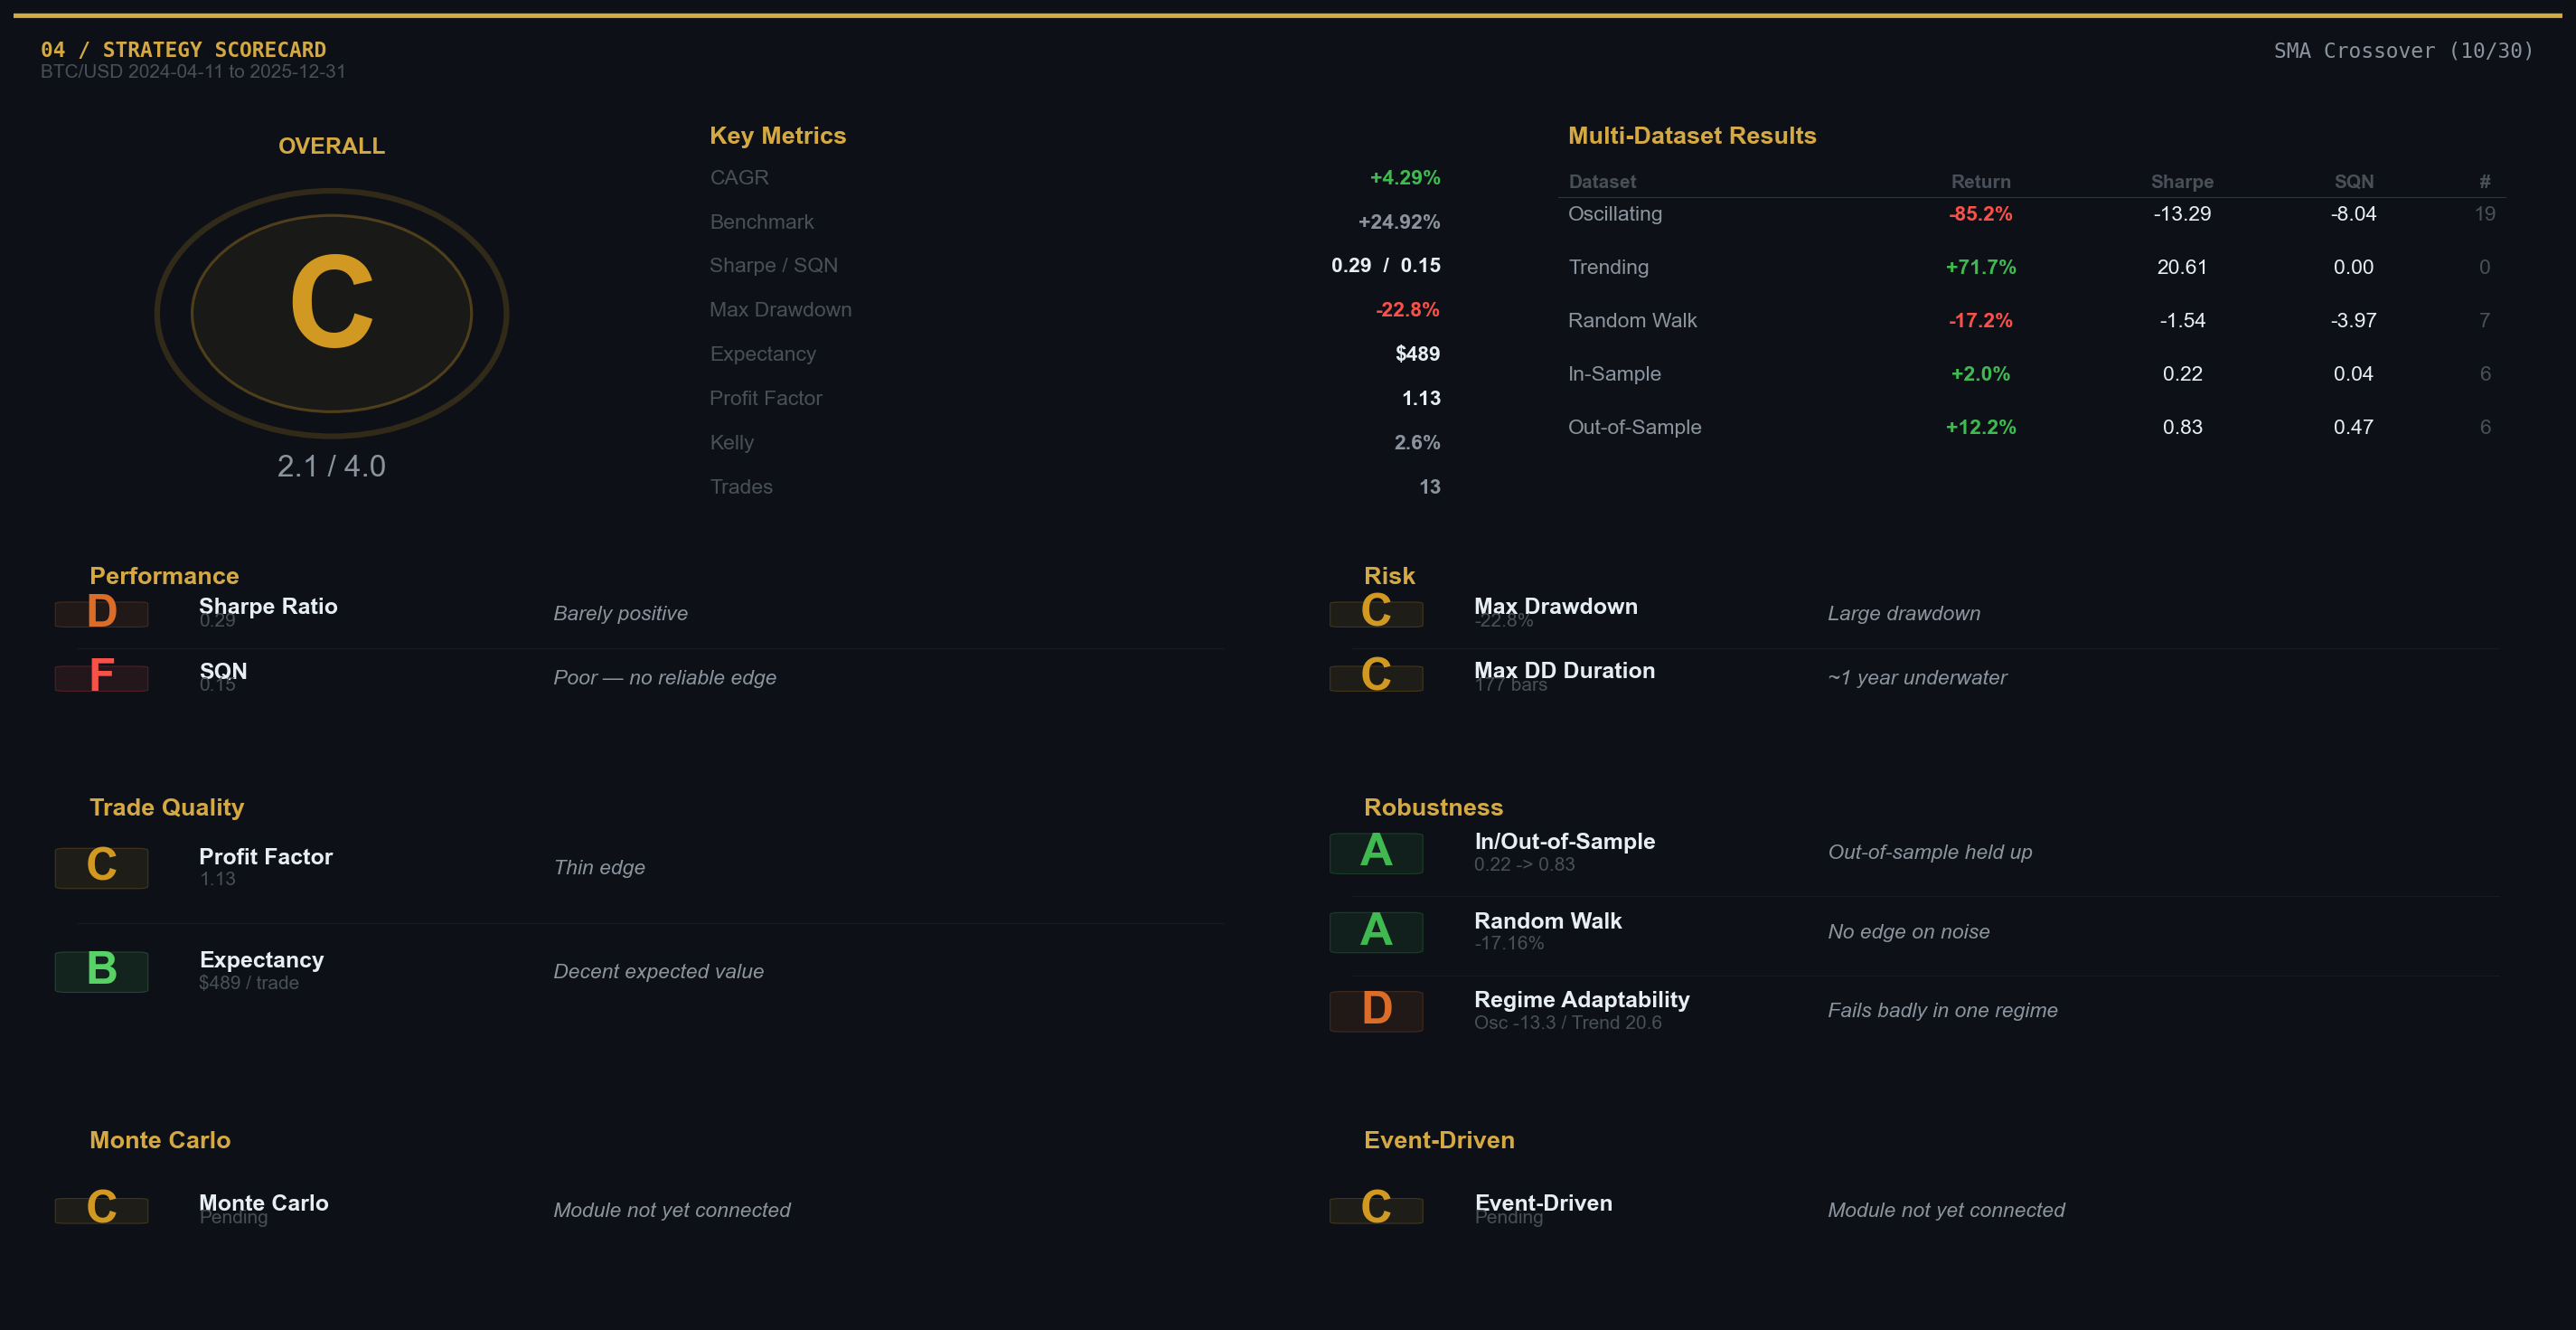

In [15]:
# Crypto scorecard
generate_scorecard(
    strategy=SMACrossover(10, 30),
    df=btc,
    config=crypto_config,
    output_path='crypto_scorecard.png',
    symbol='BTC/USD',
)
display(Image('crypto_scorecard_scorecard.png'))


---
## 9. Options Backtesting

The options engine synthesizes option prices via Black-Scholes from the underlying's realized volatility — **no historical options data needed**. Just feed it OHLCV data.

Included components:
- **GreeksEngine** — Black-Scholes pricing, all Greeks, IV solver
- **OptionsExecutor** — realistic bid-ask spread modeling
- **MarginCalculator** — Reg-T and portfolio margin
- **ExpirationHandler** — exercise, assignment, expiry
- **PositionFactory** — covered calls, verticals, iron condors, straddles

For real options chain data, use Polygon.io ($79-199/mo) or Yahoo Finance (free, limited history).


In [16]:
from strategy import CoveredCallStrategy
from backtester.options import OptionsBacktester, OptionsBacktestConfig

# Covered call on SPY: sell ~30 DTE calls at 0.30 delta, close at 50% profit
options_engine = OptionsBacktester(OptionsBacktestConfig(initial_capital=100_000))
options_result = options_engine.run(
    CoveredCallStrategy(target_dte=30, target_delta=0.30),
    df,  # same SPY data from earlier
)

print(f"Total Return:      {options_result.total_return_pct:+.2f}%")
print(f"Trades:            {options_result.num_trades}")
print(f"Win Rate:          {options_result.win_rate:.1f}%")
print(f"Sharpe Ratio:      {options_result.sharpe_ratio:.2f}")
print(f"Max Drawdown:      {options_result.max_drawdown_pct:.2f}%")
print(f"Premium Collected: ${options_result.total_premium_collected:,.2f}")
print(f"Commissions:       ${options_result.total_commissions:,.2f}")
print(f"Spread Costs:      ${options_result.total_spread_cost:,.2f}")

# Equity curve
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(options_result.equity_curve.index, options_result.equity_curve,
        label='Covered Call', linewidth=1.5, color='#d4a843')
ax.set_title('SPY — Covered Call (Δ0.30, 30 DTE)', fontsize=14)
ax.set_ylabel('Portfolio Value ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Total Return:      +39.38%
Trades:            120
Win Rate:          74.2%
Sharpe Ratio:      2.17
Max Drawdown:      -2.86%
Premium Collected: $46,001.54
Commissions:       $156.65
Spread Costs:      $1,790.86


/var/folders/ng/sj8f6d211bxfr75zt7rh669r0000gn/T/ipykernel_91080/2447077296.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [17]:
# Trade log
print("Trade Log (first 15):\n")
print(f"{'Entry':<12} {'Exit':<12} {'Type':<6} {'Strike':<8} {'P&L':>10}  {'Reason'}")
print("-" * 65)
for t in options_result.trade_log[:15]:
    print(f"{t['entry_date']!s:<12} {t['exit_date']!s:<12} "
          f"{t['option_type'].upper():<6} {t['strike']:<8.0f} "
          f"${t['pnl']:>+9.2f}  {t['exit_reason']}")


Trade Log (first 15):

Entry        Exit         Type   Strike          P&L  Reason
-----------------------------------------------------------------
2022-01-03   2022-01-06   CALL   467      $  +246.27  strategy_close
2022-01-06   2022-01-10   CALL   458      $  +343.73  strategy_close
2022-01-10   2022-01-18   CALL   450      $  +184.65  strategy_close
2022-01-18   2022-01-20   CALL   443      $  +226.71  strategy_close
2022-01-20   2022-01-21   CALL   433      $  +155.88  strategy_close
2022-01-21   2022-01-26   CALL   425      $  +165.11  strategy_close
2022-01-26   2022-02-18   CALL   420      $  +140.55  strategy_close
2022-02-18   2022-02-23   CALL   426      $  +287.61  strategy_close
2022-02-23   2022-03-08   CALL   414      $  +292.24  strategy_close
2022-03-08   2022-03-31   CALL   410      $ -1411.81  strategy_close
2022-03-31   2022-04-06   CALL   446      $  +335.81  strategy_close
2022-04-06   2022-04-12   CALL   437      $  +277.94  strategy_close
2022-04-12   2022-04-2

Options scorecard: options_scorecard.png


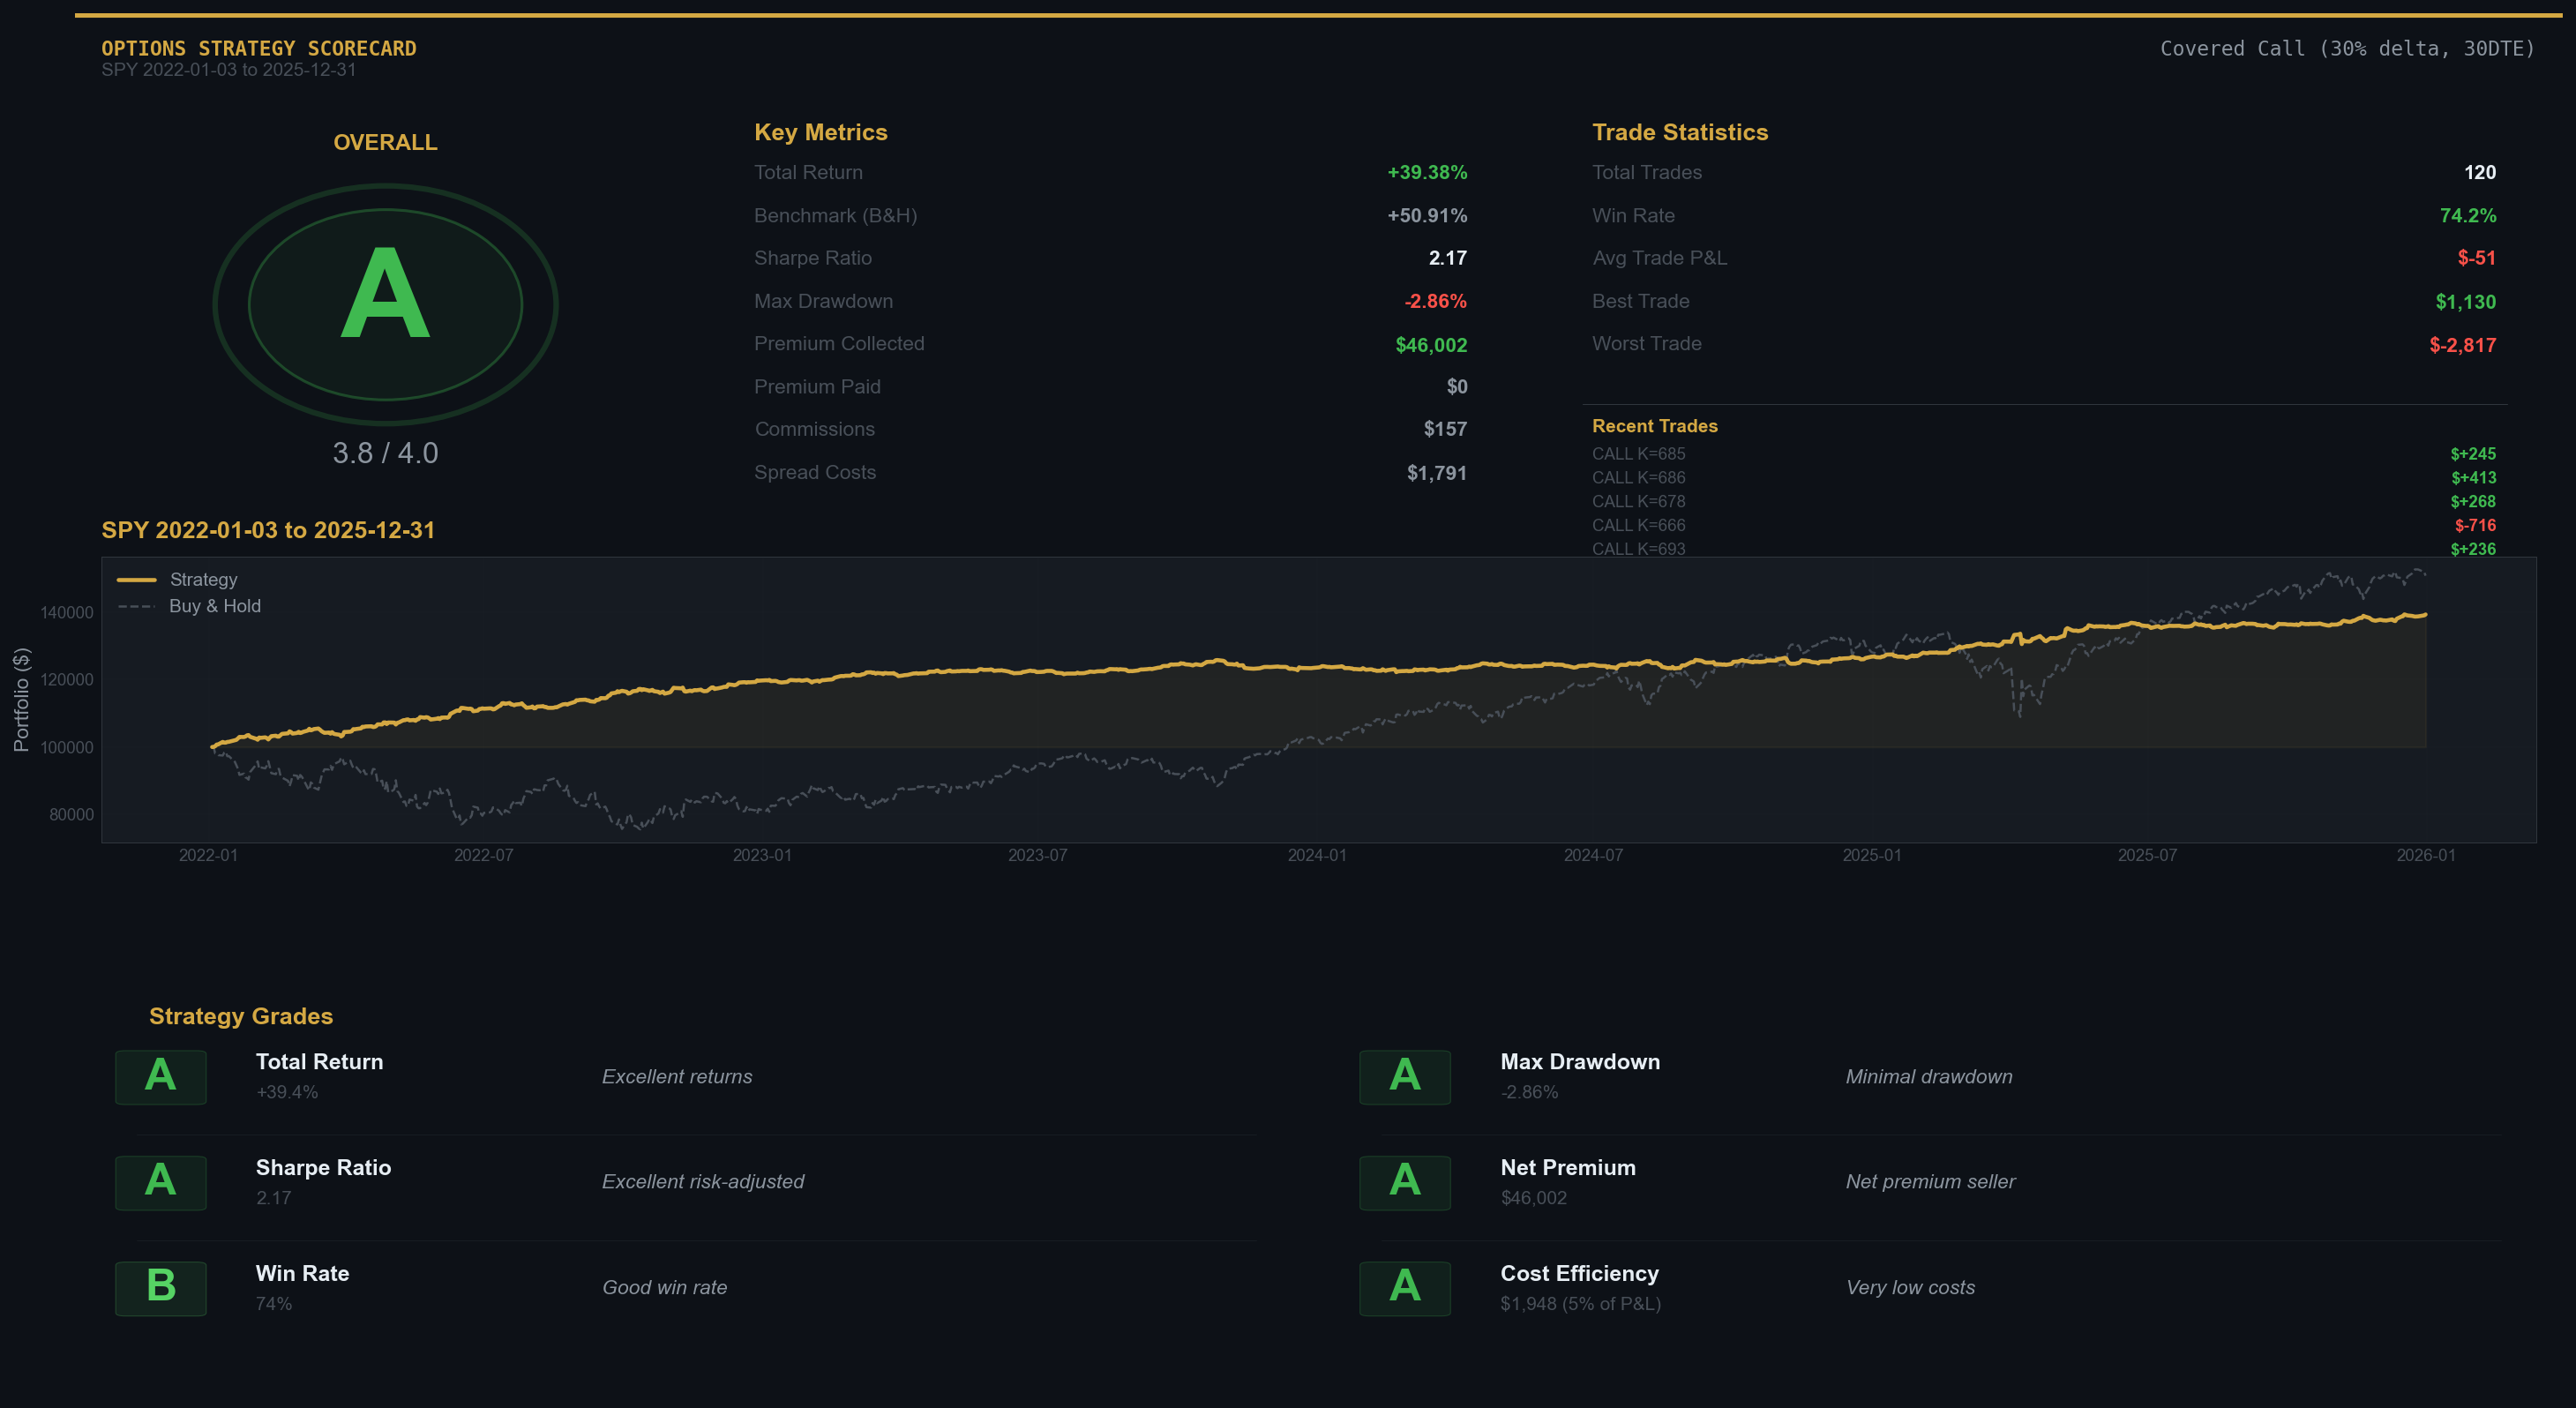

In [18]:
# Options scorecard
from backtester import generate_options_scorecard

generate_options_scorecard(
    strategy=CoveredCallStrategy(target_dte=30, target_delta=0.30),
    df=df,
    config=OptionsBacktestConfig(initial_capital=100_000),
    output_path='options_scorecard.png',
    symbol='SPY',
)
display(Image('options_scorecard.png'))
